# Anomaly Detection — wafer / unit / die 3단계

각 단위에서 동일하게:
1. **그룹 정의** — pred에 임계값(90-percentile) → high(비정상) / low(정상)
2. **단일 feature 분리력** — 인구 피라미드 (Top 12 by AUC) + AUC 분포 히스토그램
3. **파라미터 탐색** — DBSCAN eps용 k-distance plot, PCA scree plot, eps sweep
4. **2-feature 분리력** — Top 4 feature 페어 산점도
5. **다변량 압축** — PCA 2D 산점도 (group 색)
6. **다변량 클러스터링** — DBSCAN noise + p95 그룹 overlay

데이터: `5_dashboard/data/`(prediction) + `0_data/compet_xs_data.csv`(raw X)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)

USE_SPLITS = ['oof', 'val']
THR_PCT = 0.90        # 임계값 percentile
TOP_N_PYRAMID = 12     # 피라미드 그릴 feature 수
TOP_K_SCATTER = 4      # 산점도 grid 사용 feature 수
TOP_K_DBSCAN = 12      # DBSCAN/PCA 사용 feature 수 (전체 1087개 → 신호 희석)
VIZ_SAMPLE = 5000     # 산점도/DBSCAN 표본 상한 (None이면 전체)
SEED = 42

unit_pred = pd.read_parquet('5_dashboard/data/unit_predictions.parquet')
die_pred  = pd.read_parquet('5_dashboard/data/die_predictions.parquet')
xs        = pd.read_csv('0_data/compet_xs_data.csv', low_memory=False)

x_cols = [c for c in xs.columns if c.startswith('X')]
print(f'unit_pred {unit_pred.shape}, die_pred {die_pred.shape}, xs {xs.shape}')
print(f'X feature: {len(x_cols)}개')

unit_pred (43643, 12), die_pred (174572, 13), xs (174980, 1091)
X feature: 1087개


## 헬퍼 함수

**분리력 분석**: `compute_auc_table`, `plot_top_pyramids`, `plot_auc_hist`

**다변량 시각화**: `plot_top_scatter_grid`, `plot_pca_scatter`, `plot_dbscan`

**파라미터 탐색**: `plot_k_distance` (DBSCAN eps 후보), `plot_pca_scree` (PCA n_components 후보), `dbscan_sweep` (eps 변화에 따른 cluster/noise 변화)

In [2]:
def compute_auc_table(df, x_cols):
    y = (df['group'] == 'high').astype(int).values
    Xv = df[x_cols].to_numpy(dtype=np.float64)
    rows = []
    for i, c in enumerate(x_cols):
        v = Xv[:, i]
        m = ~np.isnan(v)
        if m.sum() < 50:
            continue
        v_c = v[m]
        if np.std(v_c) == 0:
            continue
        y_c = y[m]
        if y_c.sum() == 0 or y_c.sum() == len(y_c):
            continue
        try:
            a = roc_auc_score(y_c, v_c)
        except Exception:
            continue
        m_h = v_c[y_c == 1].mean()
        m_l = v_c[y_c == 0].mean()
        pooled = np.std(v_c)
        d = (m_h - m_l) / pooled if pooled > 0 else 0
        rows.append({'feature': c, 'auc': max(a, 1-a),
                     'cohen_d': d, 'mean_high': m_h, 'mean_low': m_l})
    return pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)


def _pyramid(ax, df, col, n_bins=22):
    v = df[col].dropna()
    lo, hi = v.min(), v.max()
    if lo == hi:
        ax.text(0.5, 0.5, 'no var', ha='center', va='center', transform=ax.transAxes)
        return
    edges = np.linspace(lo, hi, n_bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    width = edges[1] - edges[0]
    high = df[df['group']=='high'][col].dropna()
    low  = df[df['group']=='low'][col].dropna()
    h, _ = np.histogram(high, bins=edges)
    l, _ = np.histogram(low,  bins=edges)
    h = h / max(len(high), 1) * 100
    l = l / max(len(low),  1) * 100
    ax.barh(centers, -l, height=width*0.9, color='#94a3b8', label=f'low ({len(low)})')
    ax.barh(centers,  h, height=width*0.9, color='#ef4444', label=f'high ({len(high)})')
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_ylabel(col, fontsize=9)
    ax.set_xlabel('% of group', fontsize=8)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{abs(x):.0f}'))
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3, axis='x')


def plot_top_pyramids(df, auc_df, title, top_n=TOP_N_PYRAMID):
    top = auc_df.head(top_n)
    fig, axes = plt.subplots(3, 4, figsize=(18, 13))
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        _pyramid(ax, df, row['feature'])
        ax.set_title(f"{row['feature']} | AUC={row['auc']:.3f} | d={row['cohen_d']:+.2f}",
                     fontsize=10)
    plt.suptitle(title, fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()


def plot_auc_hist(auc_df, title):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.hist(auc_df['auc'], bins=50, color='#3b82f6', edgecolor='white')
    ax.axvline(0.5, color='k', linestyle='--', linewidth=0.8)
    ax.axvline(0.7, color='#ef4444', linestyle='--', linewidth=0.8, label='AUC=0.7')
    ax.axvline(0.9, color='#16a34a', linestyle='--', linewidth=0.8, label='AUC=0.9')
    ax.set_xlabel('AUC')
    ax.set_ylabel('feature 수')
    ax.set_title(f'{title} (max={auc_df["auc"].max():.3f}, '
                 f'≥0.7: {(auc_df["auc"]>=0.7).sum()}, ≥0.8: {(auc_df["auc"]>=0.8).sum()})')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [3]:
def _subsample(df, n=VIZ_SAMPLE):
    if n is None or len(df) <= n:
        return df
    return df.sample(n, random_state=SEED)


def _prep_X(df, x_cols, top_k=None, auc_df=None):
    feats = auc_df.head(top_k)['feature'].tolist() if (top_k and auc_df is not None) else x_cols
    X = df[feats].copy().fillna(df[feats].median(numeric_only=True))
    valid = X.std(axis=0) > 0
    X = X.loc[:, valid]
    Xs = StandardScaler().fit_transform(X.values)
    return Xs, X.columns.tolist()


def plot_top_scatter_grid(df, auc_df, title, top_k=TOP_K_SCATTER, sample=VIZ_SAMPLE):
    feats = auc_df.head(top_k)['feature'].tolist()
    pairs = [(feats[i], feats[j]) for i in range(top_k) for j in range(i+1, top_k)]
    df_s = _subsample(df, sample)
    n = len(pairs)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    axes = np.atleast_2d(axes).ravel()
    for ax, (fx, fy) in zip(axes, pairs):
        for grp, color, a, sz in [('low', '#94a3b8', 0.35, 8), ('high', '#ef4444', 0.7, 14)]:
            sub = df_s[df_s['group']==grp]
            ax.scatter(sub[fx], sub[fy], s=sz, c=color, alpha=a,
                       edgecolor='none', label=f'{grp} ({len(sub)})')
        ax.set_xlabel(fx, fontsize=9)
        ax.set_ylabel(fy, fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    for ax in axes[len(pairs):]:
        ax.axis('off')
    plt.suptitle(title, fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()


def plot_pca_scatter(df, x_cols, title, top_k=None, auc_df=None, sample=VIZ_SAMPLE):
    df_s = _subsample(df, sample)
    Xs, _ = _prep_X(df_s, x_cols, top_k, auc_df)
    pca = PCA(n_components=2, random_state=SEED).fit(Xs)
    pcs = pca.transform(Xs)
    fig, ax = plt.subplots(figsize=(9, 7))
    grp = df_s['group'].values
    for g, color, a, sz in [('low', '#94a3b8', 0.35, 10), ('high', '#ef4444', 0.7, 18)]:
        m = grp == g
        ax.scatter(pcs[m, 0], pcs[m, 1], s=sz, c=color, alpha=a,
                   edgecolor='none', label=f'{g} ({m.sum()})')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(f'{title} — PCA (총 설명력 {pca.explained_variance_ratio_.sum()*100:.1f}%)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return pcs


def plot_dbscan(df, x_cols, title, eps=0.7, min_samples=5,
                top_k=TOP_K_DBSCAN, auc_df=None, sample=VIZ_SAMPLE):
    df_s = _subsample(df, sample)
    Xs, used = _prep_X(df_s, x_cols, top_k, auc_df)
    print(f'  DBSCAN input: n={len(df_s)}, features={len(used)}, eps={eps}, min_samples={min_samples}')
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xs)
    n_clu = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    print(f'  cluster: {n_clu}, noise: {n_noise}/{len(labels)}')
    pcs = PCA(n_components=2, random_state=SEED).fit_transform(Xs)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    ax = axes[0]
    for lbl in sorted(set(labels)):
        m = labels == lbl
        color = '#ef4444' if lbl == -1 else plt.cm.tab10(lbl % 10)
        lab = f'noise ({m.sum()})' if lbl == -1 else f'c{lbl} ({m.sum()})'
        ax.scatter(pcs[m, 0], pcs[m, 1], s=14 if lbl != -1 else 22,
                   c=[color], alpha=0.55 if lbl != -1 else 0.85,
                   edgecolor='none', label=lab)
    ax.set_title(f'DBSCAN cluster (eps={eps}, min={min_samples})')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    ax = axes[1]
    grp = df_s['group'].values
    for g, color in [('low', '#94a3b8'), ('high', '#f59e0b')]:
        m = grp == g
        ax.scatter(pcs[m, 0], pcs[m, 1], s=12, c=color, alpha=0.45,
                   edgecolor='none', label=f'{g} ({m.sum()})')
    nm = labels == -1
    ax.scatter(pcs[nm, 0], pcs[nm, 1], s=40, facecolor='none',
               edgecolor='#ef4444', linewidth=1.4, label=f'DBSCAN noise ({nm.sum()})')
    ax.set_title('group + DBSCAN noise overlay')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    overlap = pd.crosstab(df_s['group'].values, labels == -1,
                           rownames=['group'], colnames=['noise'])
    print('  group × noise:')
    print(overlap)

In [4]:
def plot_k_distance(df, x_cols, title, top_k=TOP_K_DBSCAN, auc_df=None,
                     k_values=(5, 10, 20), sample=VIZ_SAMPLE):
    """k-distance plot — DBSCAN eps 후보 탐색.
    각 점의 k-th nearest neighbor까지 거리를 정렬한 그래프.
    그래프가 급격히 꺾이는 지점(elbow)이 eps 후보."""
    df_s = _subsample(df, sample)
    Xs, _ = _prep_X(df_s, x_cols, top_k, auc_df)
    fig, ax = plt.subplots(figsize=(11, 5))
    quantiles = [0.85, 0.90, 0.95]
    for k in k_values:
        nbrs = NearestNeighbors(n_neighbors=k+1).fit(Xs)
        dists, _ = nbrs.kneighbors(Xs)
        k_dist = np.sort(dists[:, k])
        ax.plot(k_dist, label=f'k={k} (min_samples 후보)', linewidth=1.5)
    ax.set_xlabel('points (sorted by k-distance)')
    ax.set_ylabel('distance to k-th neighbor')
    ax.set_title(f'{title} — k-distance plot (꺾이는 지점이 eps 후보)')
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # 추천값 출력 (k=5의 q-quantile)
    nbrs = NearestNeighbors(n_neighbors=11).fit(Xs)
    dists, _ = nbrs.kneighbors(Xs)
    print('  추천 eps 후보 (k=10 분위수):')
    for q in [0.80, 0.85, 0.90, 0.95]:
        v = np.quantile(dists[:, 10], q)
        print(f'    {int(q*100)}-pct: eps ≈ {v:.3f}')


def plot_pca_scree(df, x_cols, title, top_k=None, auc_df=None,
                    n_components=20, sample=VIZ_SAMPLE):
    """Scree plot — PCA n_components 후보 탐색.
    누적 explained variance가 80/90/95%에 도달하는 component 수 표시."""
    df_s = _subsample(df, sample)
    Xs, used = _prep_X(df_s, x_cols, top_k, auc_df)
    n_comp = min(n_components, Xs.shape[1], Xs.shape[0])
    pca = PCA(n_components=n_comp, random_state=SEED).fit(Xs)
    cum = np.cumsum(pca.explained_variance_ratio_)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax = axes[0]
    ax.bar(range(1, len(pca.explained_variance_ratio_)+1),
           pca.explained_variance_ratio_, color='#3b82f6')
    ax.set_xlabel('component #')
    ax.set_ylabel('explained variance ratio')
    ax.set_title(f'{title} — scree (features={len(used)}개)')
    ax.grid(alpha=0.3)

    ax = axes[1]
    ax.plot(range(1, len(cum)+1), cum, marker='o', color='#16a34a')
    print(f'  PCA cumulative variance:')
    for thr in [0.80, 0.90, 0.95]:
        idx = np.argmax(cum >= thr) if (cum >= thr).any() else None
        if idx is not None:
            n_at = idx + 1
            ax.axhline(thr, linestyle='--', alpha=0.4, color='gray')
            ax.axvline(n_at, linestyle='--', alpha=0.4, color='gray')
            ax.annotate(f'{int(thr*100)}%: {n_at}개', xy=(n_at, thr),
                        xytext=(5, -10), textcoords='offset points', fontsize=9)
            print(f'    {int(thr*100)}% 도달: component {n_at}개')
        else:
            print(f'    {int(thr*100)}% 도달 안 됨 (max={cum[-1]:.3f})')
    ax.set_xlabel('component 수')
    ax.set_ylabel('cumulative explained variance')
    ax.set_title('cumulative scree')
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def dbscan_sweep(df, x_cols, title, top_k=TOP_K_DBSCAN, auc_df=None,
                  eps_values=None, min_samples=5, sample=VIZ_SAMPLE):
    """eps 변화에 따른 cluster 수 / noise 비율 / noise 안의 group 비율.
    이상적인 eps: cluster 1~2개로 안정 + noise 비율이 적당(5~30%) + noise에 high 비율 높음."""
    df_s = _subsample(df, sample)
    Xs, _ = _prep_X(df_s, x_cols, top_k, auc_df)
    if eps_values is None:
        eps_values = np.linspace(0.3, 2.0, 18)
    grp = df_s['group'].values
    n_total = len(grp)
    n_high_total = (grp == 'high').sum()

    rec = []
    for eps in eps_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(Xs)
        nc = len(set(labels)) - (1 if -1 in labels else 0)
        nm = labels == -1
        if nm.sum() > 0:
            high_in_noise = (grp[nm] == 'high').sum()
            recall_high = high_in_noise / max(n_high_total, 1) * 100  # high 중 noise로 잡힌 비율
            precision = high_in_noise / nm.sum() * 100                  # noise 중 high인 비율
        else:
            recall_high = 0
            precision = 0
        rec.append({'eps': eps, 'n_cluster': nc, 'noise_pct': nm.sum()/n_total*100,
                    'recall_high': recall_high, 'precision_high': precision})
    swp = pd.DataFrame(rec)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    ax = axes[0]
    ax.plot(swp['eps'], swp['n_cluster'], marker='o', color='#3b82f6')
    ax.set_xlabel('eps'); ax.set_ylabel('cluster 수')
    ax.set_title('eps vs cluster count'); ax.grid(alpha=0.3)
    ax = axes[1]
    ax.plot(swp['eps'], swp['noise_pct'], marker='o', color='#ef4444')
    ax.set_xlabel('eps'); ax.set_ylabel('noise 비율 (%)')
    ax.set_title('eps vs noise %'); ax.grid(alpha=0.3)
    ax = axes[2]
    ax.plot(swp['eps'], swp['recall_high'], marker='o', color='#ef4444', label='recall (high∩noise / high)')
    ax.plot(swp['eps'], swp['precision_high'], marker='s', color='#f59e0b', label='precision (high∩noise / noise)')
    ax.set_xlabel('eps'); ax.set_ylabel('%')
    ax.set_title('eps vs noise–high 일치도'); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle(f'{title} — DBSCAN eps sweep (min_samples={min_samples})', y=1.02)
    plt.tight_layout()
    plt.show()
    return swp

## A. WAFER 단위 (~431 wafer)

그룹 정의: wafer-level **p95(pred)** 의 90-percentile 임계값.

In [5]:
u_w = unit_pred[unit_pred['split'].isin(USE_SPLITS)].copy()
wafer_g = u_w.groupby('wafer_key').agg(p95_pred=('pred', lambda s: s.quantile(0.95))).reset_index()
thr_w = wafer_g['p95_pred'].quantile(THR_PCT)
wafer_g['group'] = np.where(wafer_g['p95_pred'] >= thr_w, 'high', 'low')
print(f'wafer thr (p95의 {THR_PCT*100:.0f}-pct) = {thr_w:.5f}')
print(wafer_g['group'].value_counts())

ufs_to_wafer = u_w.set_index('ufs_serial')['wafer_key'].to_dict()
xs_w = xs[xs['ufs_serial'].isin(ufs_to_wafer)].copy()
xs_w['wafer_key'] = xs_w['ufs_serial'].map(ufs_to_wafer)
wafer_x = xs_w.groupby('wafer_key')[x_cols].mean()
wafer_x = wafer_x.merge(wafer_g.set_index('wafer_key')[['group']],
                         left_index=True, right_index=True)
print(f'wafer_x: {wafer_x.shape}')

auc_wafer = compute_auc_table(wafer_x, x_cols)
print(f'유효 feature: {len(auc_wafer)}, ≥0.7: {(auc_wafer["auc"]>=0.7).sum()}, '
      f'≥0.8: {(auc_wafer["auc"]>=0.8).sum()}, max: {auc_wafer["auc"].max():.3f}')
auc_wafer.head(15)

wafer thr (p95의 90-pct) = 0.00367
group
low     387
high     44
Name: count, dtype: int64
wafer_x: (431, 1088)
유효 feature: 989, ≥0.7: 136, ≥0.8: 3, max: 0.831


,feature,auc,cohen_d,mean_high,mean_low
0,X769,0.831307,1.209122,-292.393607,-325.103455
1,X344,0.816714,-1.118743,5.289687,5.701261
2,X739,0.806407,1.102567,-362.509323,-403.892881
3,X774,0.797862,1.207856,1631.569696,1555.320813
4,X876,0.795689,-1.225226,1134.344452,1206.963318
5,X844,0.791872,-0.991987,398.199691,451.888785
6,X734,0.790698,1.204654,-1157.448037,-1229.651666
7,X870,0.786352,0.888224,519.611822,440.751497
8,X744,0.784649,1.025062,56.135328,-32.879432
9,X871,0.782770,0.894490,422.934043,344.800498


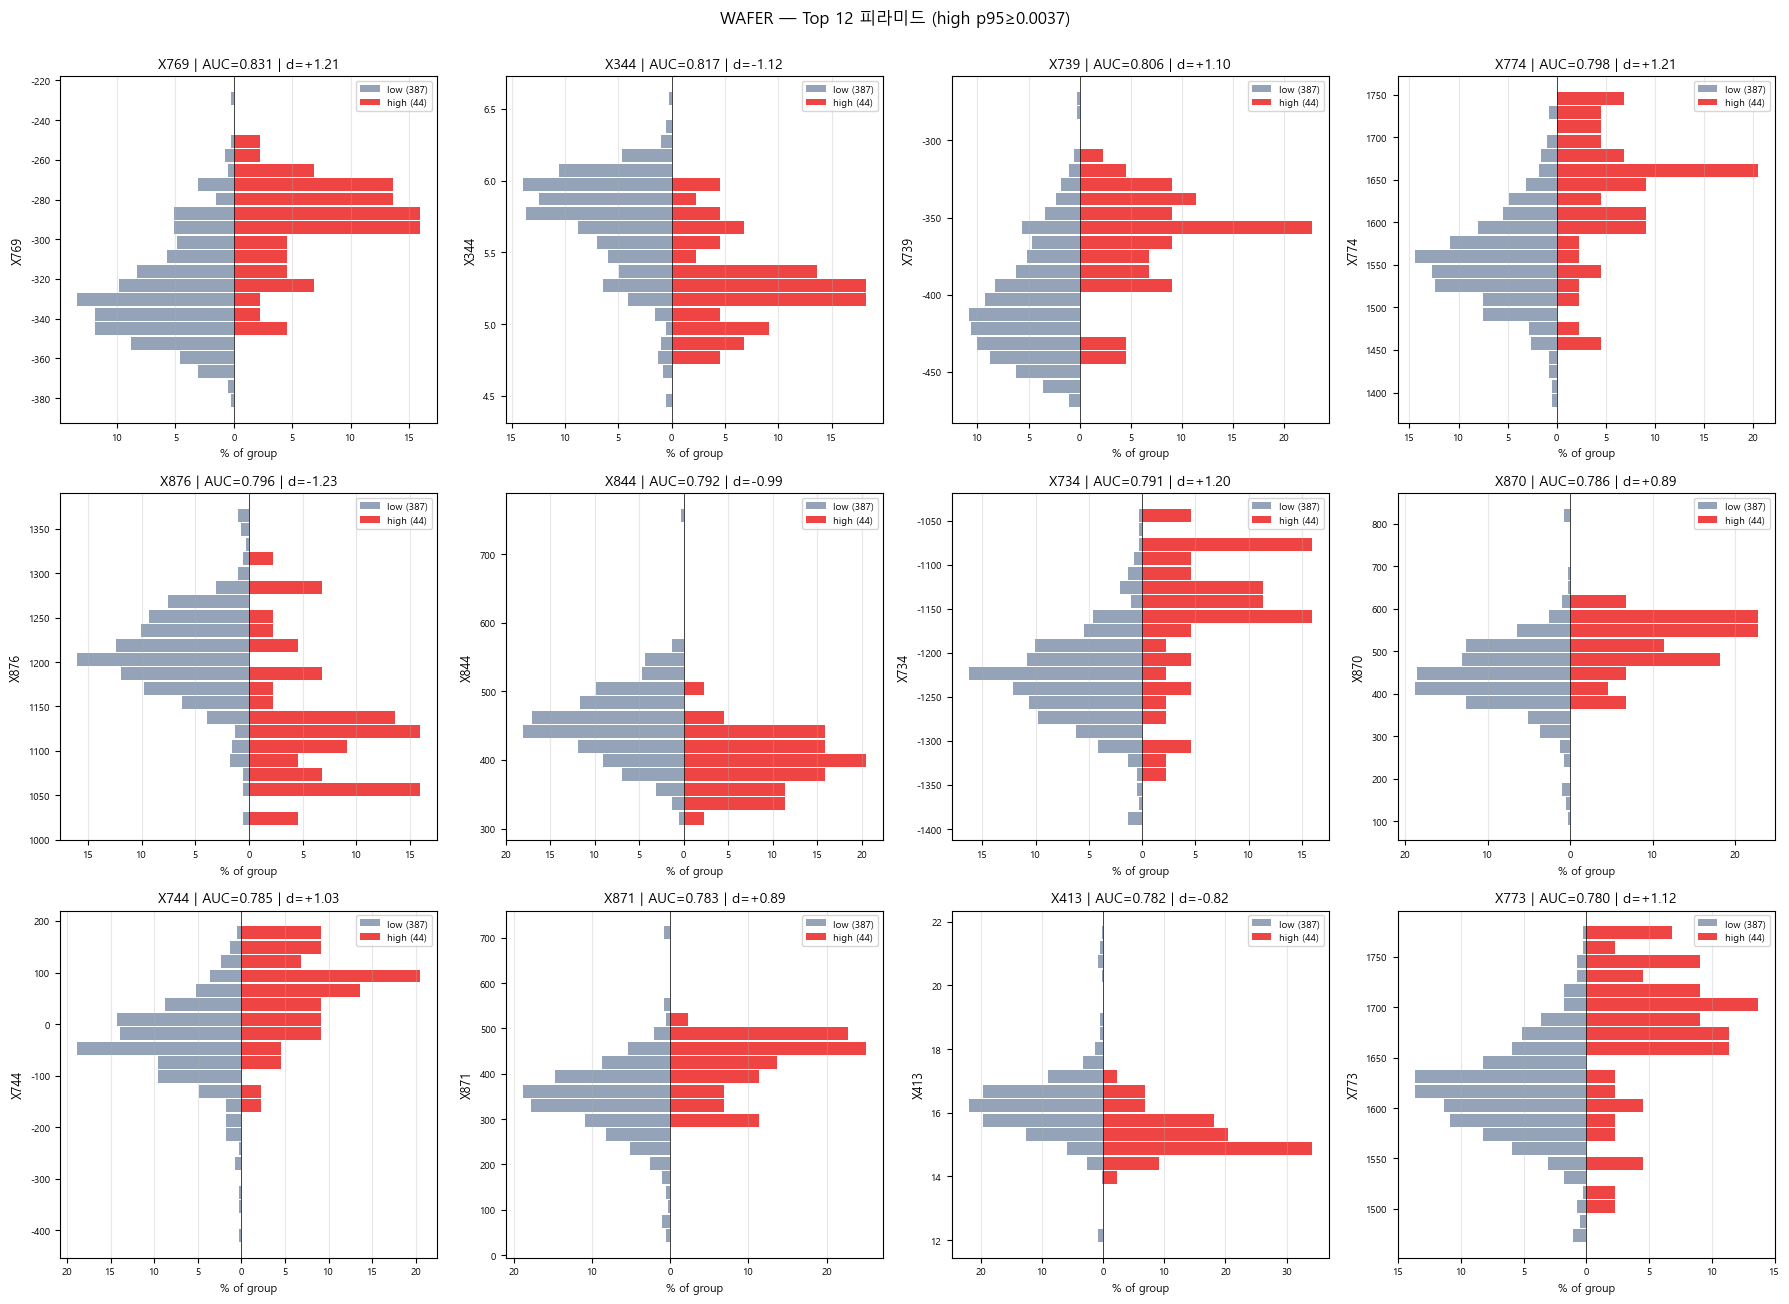

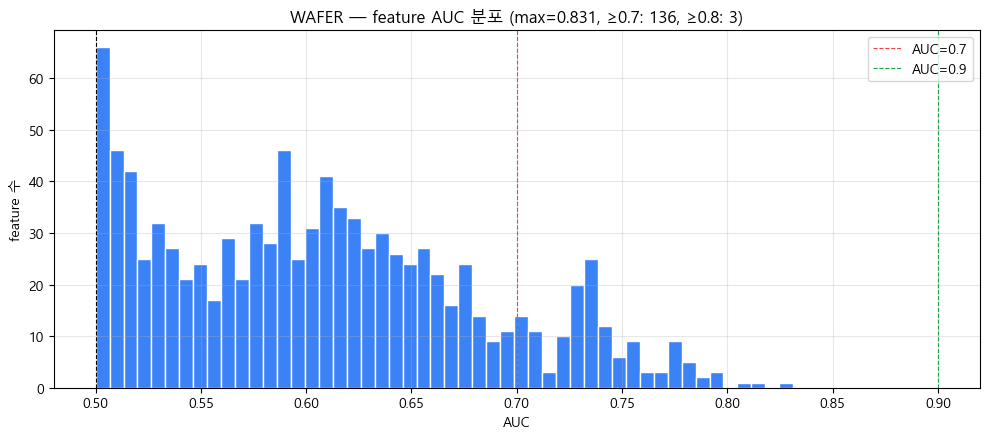

In [6]:
plot_top_pyramids(wafer_x, auc_wafer, f'WAFER — Top {TOP_N_PYRAMID} 피라미드 (high p95≥{thr_w:.4f})')
plot_auc_hist(auc_wafer, 'WAFER — feature AUC 분포')

### A-탐색: WAFER 파라미터 진단

- **k-distance plot**: DBSCAN `eps` 후보 (꺾이는 지점)
- **scree plot**: PCA n_components 후보 (80/90/95% 누적 도달 위치)
- **eps sweep**: eps 따른 cluster 수 / noise % / noise-high 일치도

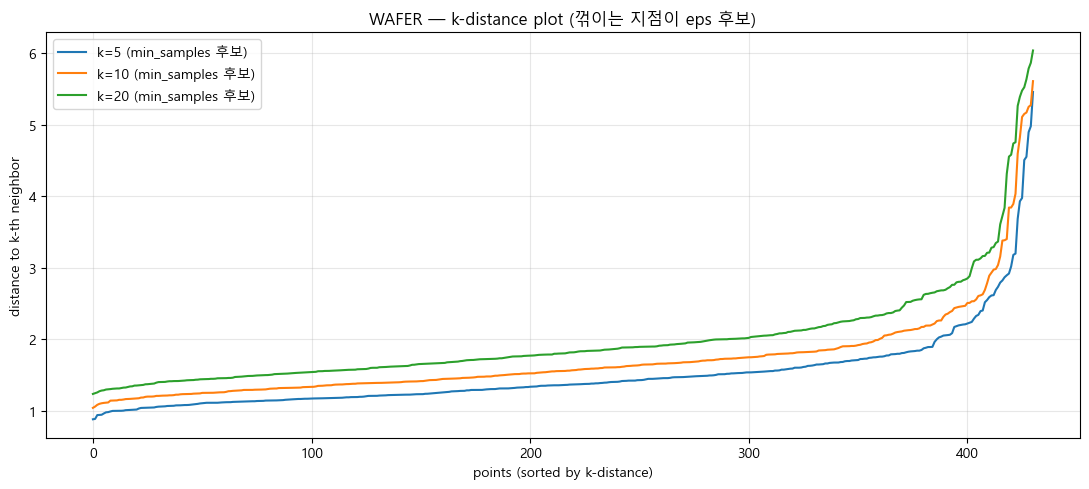

  추천 eps 후보 (k=10 분위수):
    80-pct: eps ≈ 1.903
    85-pct: eps ≈ 2.074
    90-pct: eps ≈ 2.263
    95-pct: eps ≈ 2.738
  PCA cumulative variance:
    80% 도달: component 3개
    90% 도달: component 3개
    95% 도달: component 4개


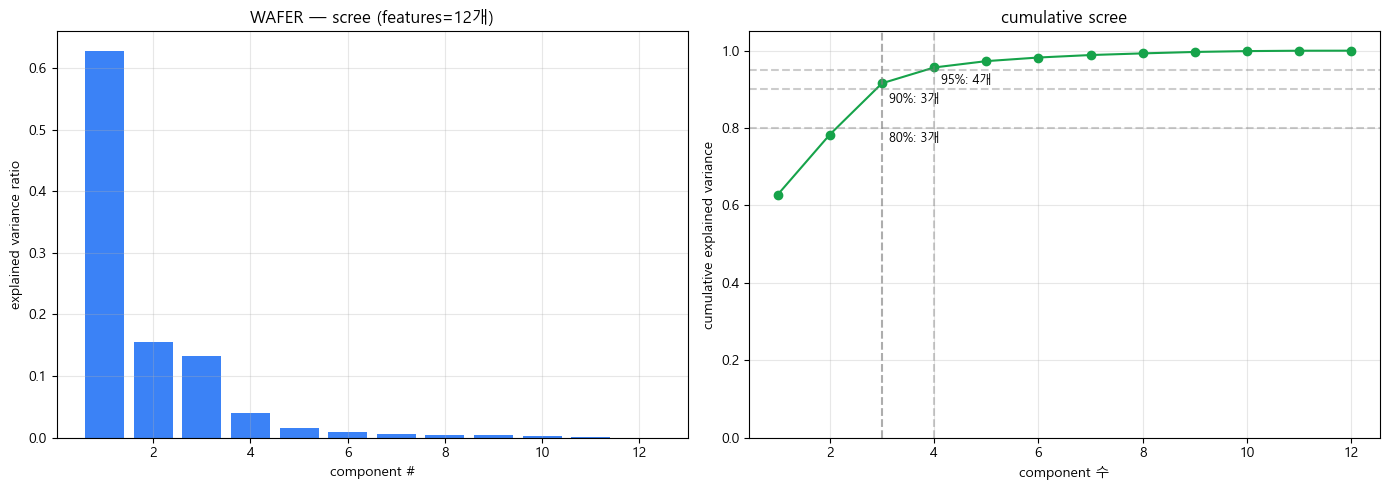

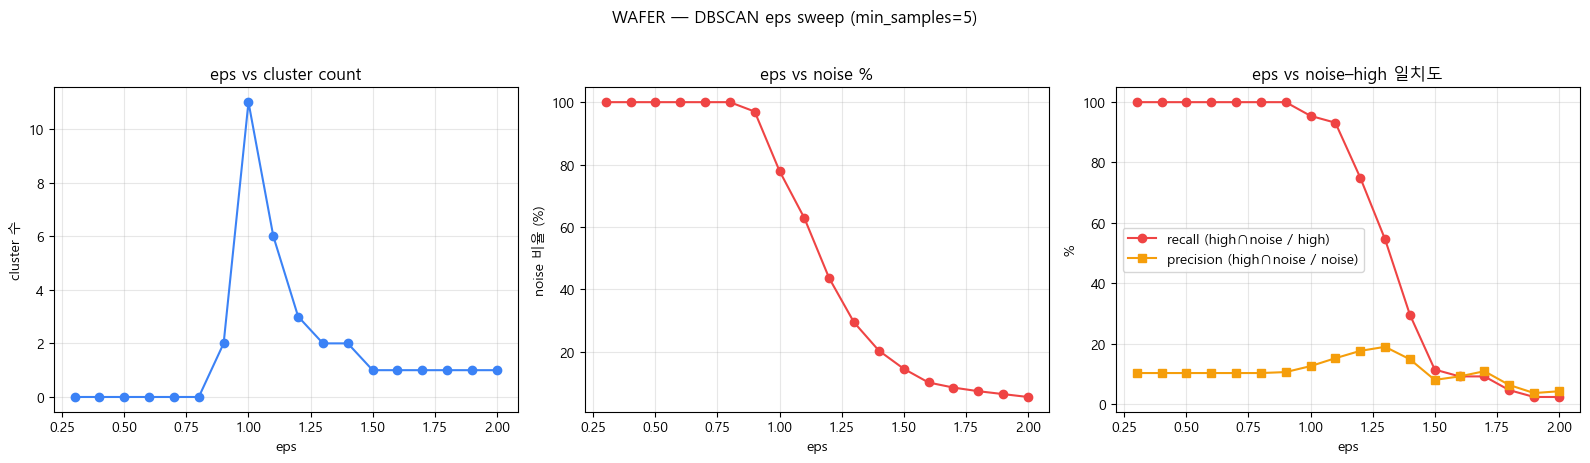

,eps,n_cluster,noise_pct,recall_high,precision_high
0,0.3,0,100.00,100.00,10.21
1,0.4,0,100.00,100.00,10.21
2,0.5,0,100.00,100.00,10.21
3,0.6,0,100.00,100.00,10.21
4,0.7,0,100.00,100.00,10.21
5,0.8,0,100.00,100.00,10.21
6,0.9,2,96.98,100.00,10.53
7,1.0,11,77.96,95.45,12.50
8,1.1,6,62.88,93.18,15.13
9,1.2,3,43.62,75.00,17.55


In [7]:
plot_k_distance(wafer_x, x_cols, 'WAFER', top_k=TOP_K_DBSCAN, auc_df=auc_wafer)
plot_pca_scree(wafer_x, x_cols, 'WAFER', top_k=TOP_K_DBSCAN, auc_df=auc_wafer)
swp_wafer = dbscan_sweep(wafer_x, x_cols, 'WAFER', top_k=TOP_K_DBSCAN, auc_df=auc_wafer,
                          min_samples=5)
swp_wafer.round(2)

### A-시각화: WAFER 산점도 + PCA + DBSCAN

위 진단 결과 보고 `eps`/`min_samples` 조정. 기본값은 일반적으로 무난한 값.

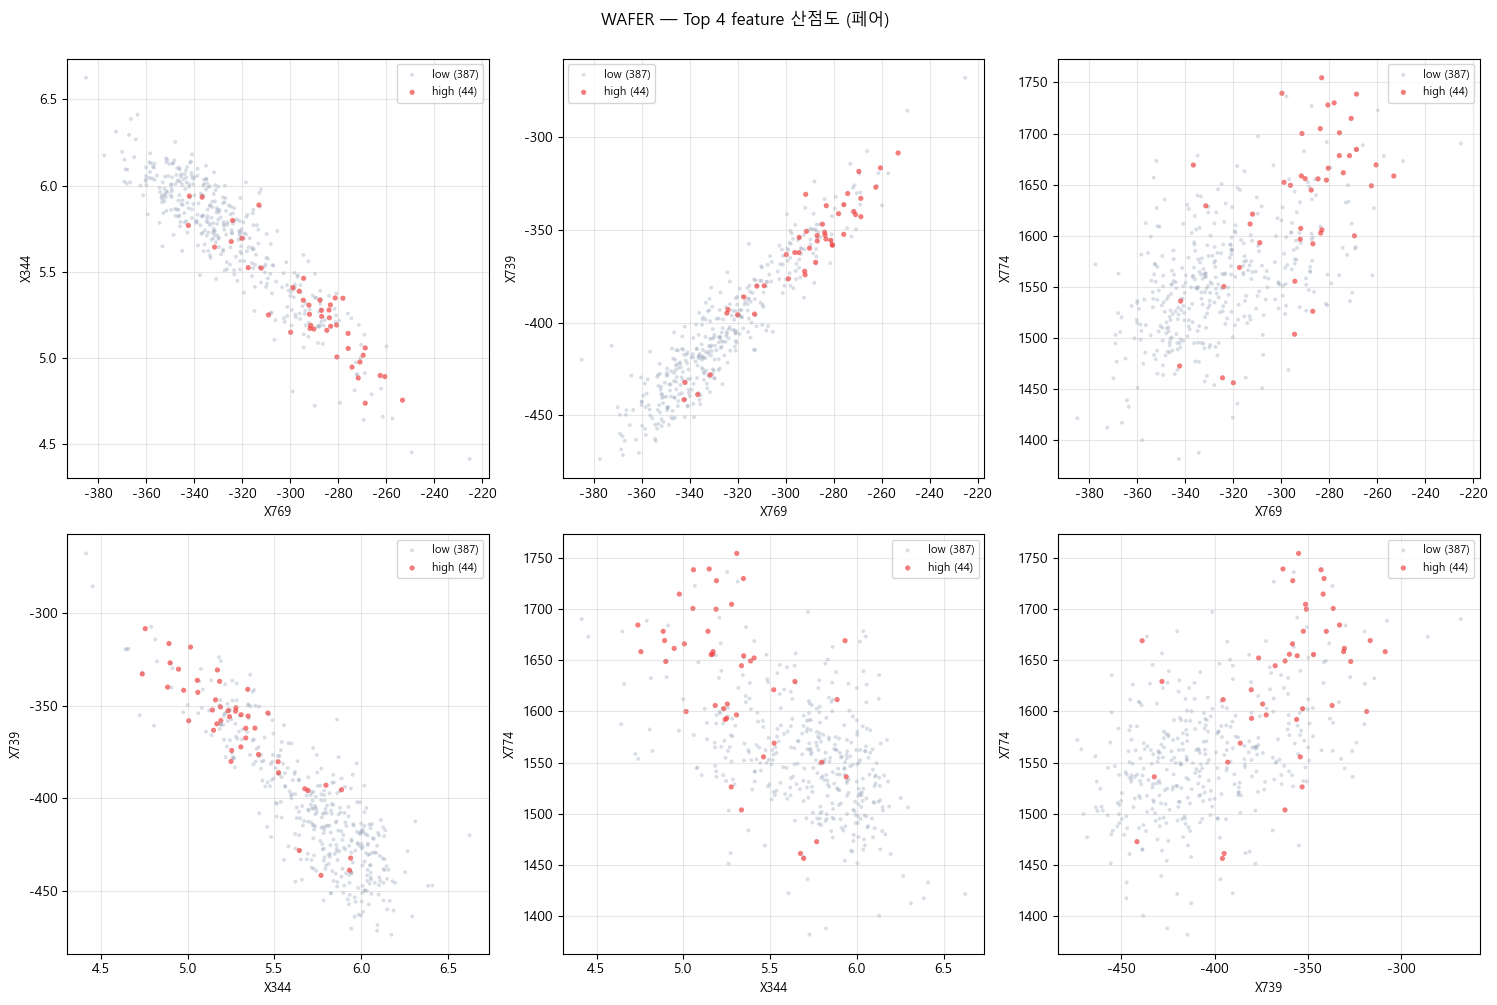

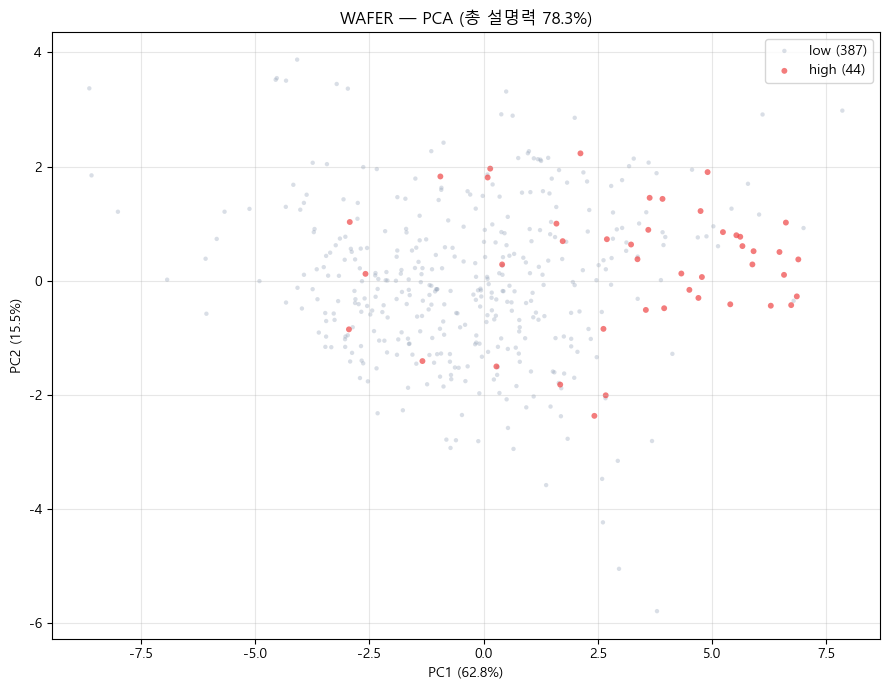

  DBSCAN input: n=431, features=12, eps=1.3, min_samples=5
  cluster: 2, noise: 127/431


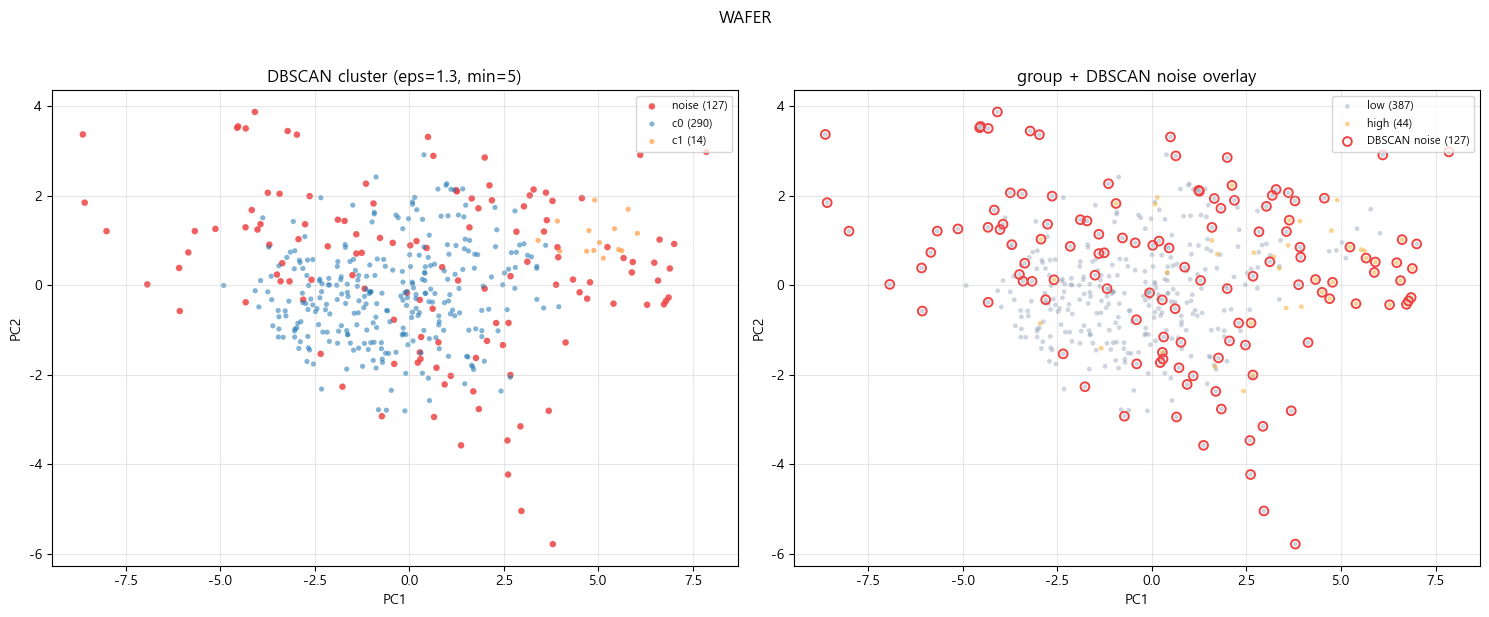

  group × noise:
noise  False  True 
group              
high      20     24
low      284    103


In [8]:
# 진단 결과 기반 최적값:
# - k-distance(k=10) elbow ≈ 1.3~1.5, 90-pct quantile = 2.26
# - eps sweep: eps=1.3에서 cluster=2 (안정), noise=29%, recall=55%, precision=19% (peak)
# - eps<1.0: noise=100% (eps 너무 작음), eps>1.5: cluster=1 (과결합)
# - scree: 80%/90%/95% 누적 설명력 = 3/3/4 components → 2D PCA(78%)로 충분
WAFER_EPS = 1.3
WAFER_MIN_SAMPLES = 5

plot_top_scatter_grid(wafer_x, auc_wafer, f'WAFER — Top {TOP_K_SCATTER} feature 산점도 (페어)')
plot_pca_scatter(wafer_x, x_cols, 'WAFER', top_k=TOP_K_DBSCAN, auc_df=auc_wafer)
plot_dbscan(wafer_x, x_cols, 'WAFER', eps=WAFER_EPS, min_samples=WAFER_MIN_SAMPLES,
            top_k=TOP_K_DBSCAN, auc_df=auc_wafer)

## B. UNIT 단위 (~34,914 unit)

그룹 정의: unit-level **pred** 의 90-percentile.

In [9]:
u_u = unit_pred[unit_pred['split'].isin(USE_SPLITS)].copy()
thr_u = u_u['pred'].quantile(THR_PCT)
u_u['group'] = np.where(u_u['pred'] >= thr_u, 'high', 'low')
print(f'unit thr (pred의 {THR_PCT*100:.0f}-pct) = {thr_u:.5f}')
print(u_u['group'].value_counts())

xs_u = xs[xs['ufs_serial'].isin(u_u['ufs_serial'])].copy()
unit_x = xs_u.groupby('ufs_serial')[x_cols].mean()
unit_x = unit_x.merge(u_u.set_index('ufs_serial')[['group']],
                       left_index=True, right_index=True)
print(f'unit_x: {unit_x.shape}')

auc_unit = compute_auc_table(unit_x, x_cols)
print(f'유효 feature: {len(auc_unit)}, ≥0.7: {(auc_unit["auc"]>=0.7).sum()}, '
      f'≥0.8: {(auc_unit["auc"]>=0.8).sum()}, max: {auc_unit["auc"].max():.3f}')
auc_unit.head(15)

unit thr (pred의 90-pct) = 0.00345
group
low     31422
high     3492
Name: count, dtype: int64
unit_x: (34914, 1088)
유효 feature: 988, ≥0.7: 35, ≥0.8: 0, max: 0.771


,feature,auc,cohen_d,mean_high,mean_low
0,X774,0.771058,0.958708,1645.701604,1557.246515
1,X773,0.760866,0.910075,1690.652921,1617.639870
2,X876,0.760841,-0.885902,1118.359107,1204.925742
3,X739,0.760261,0.916924,-357.835052,-403.365795
4,X770,0.759797,0.917307,1636.723940,1566.105277
5,X734,0.758315,0.873100,-1140.518328,-1227.679969
6,X772,0.758097,0.901161,1668.221649,1597.664694
7,X771,0.756106,0.900122,1632.061856,1562.016740
8,X744,0.755941,0.847447,71.924399,-28.726688
9,X769,0.749732,0.891024,-287.305269,-324.373581


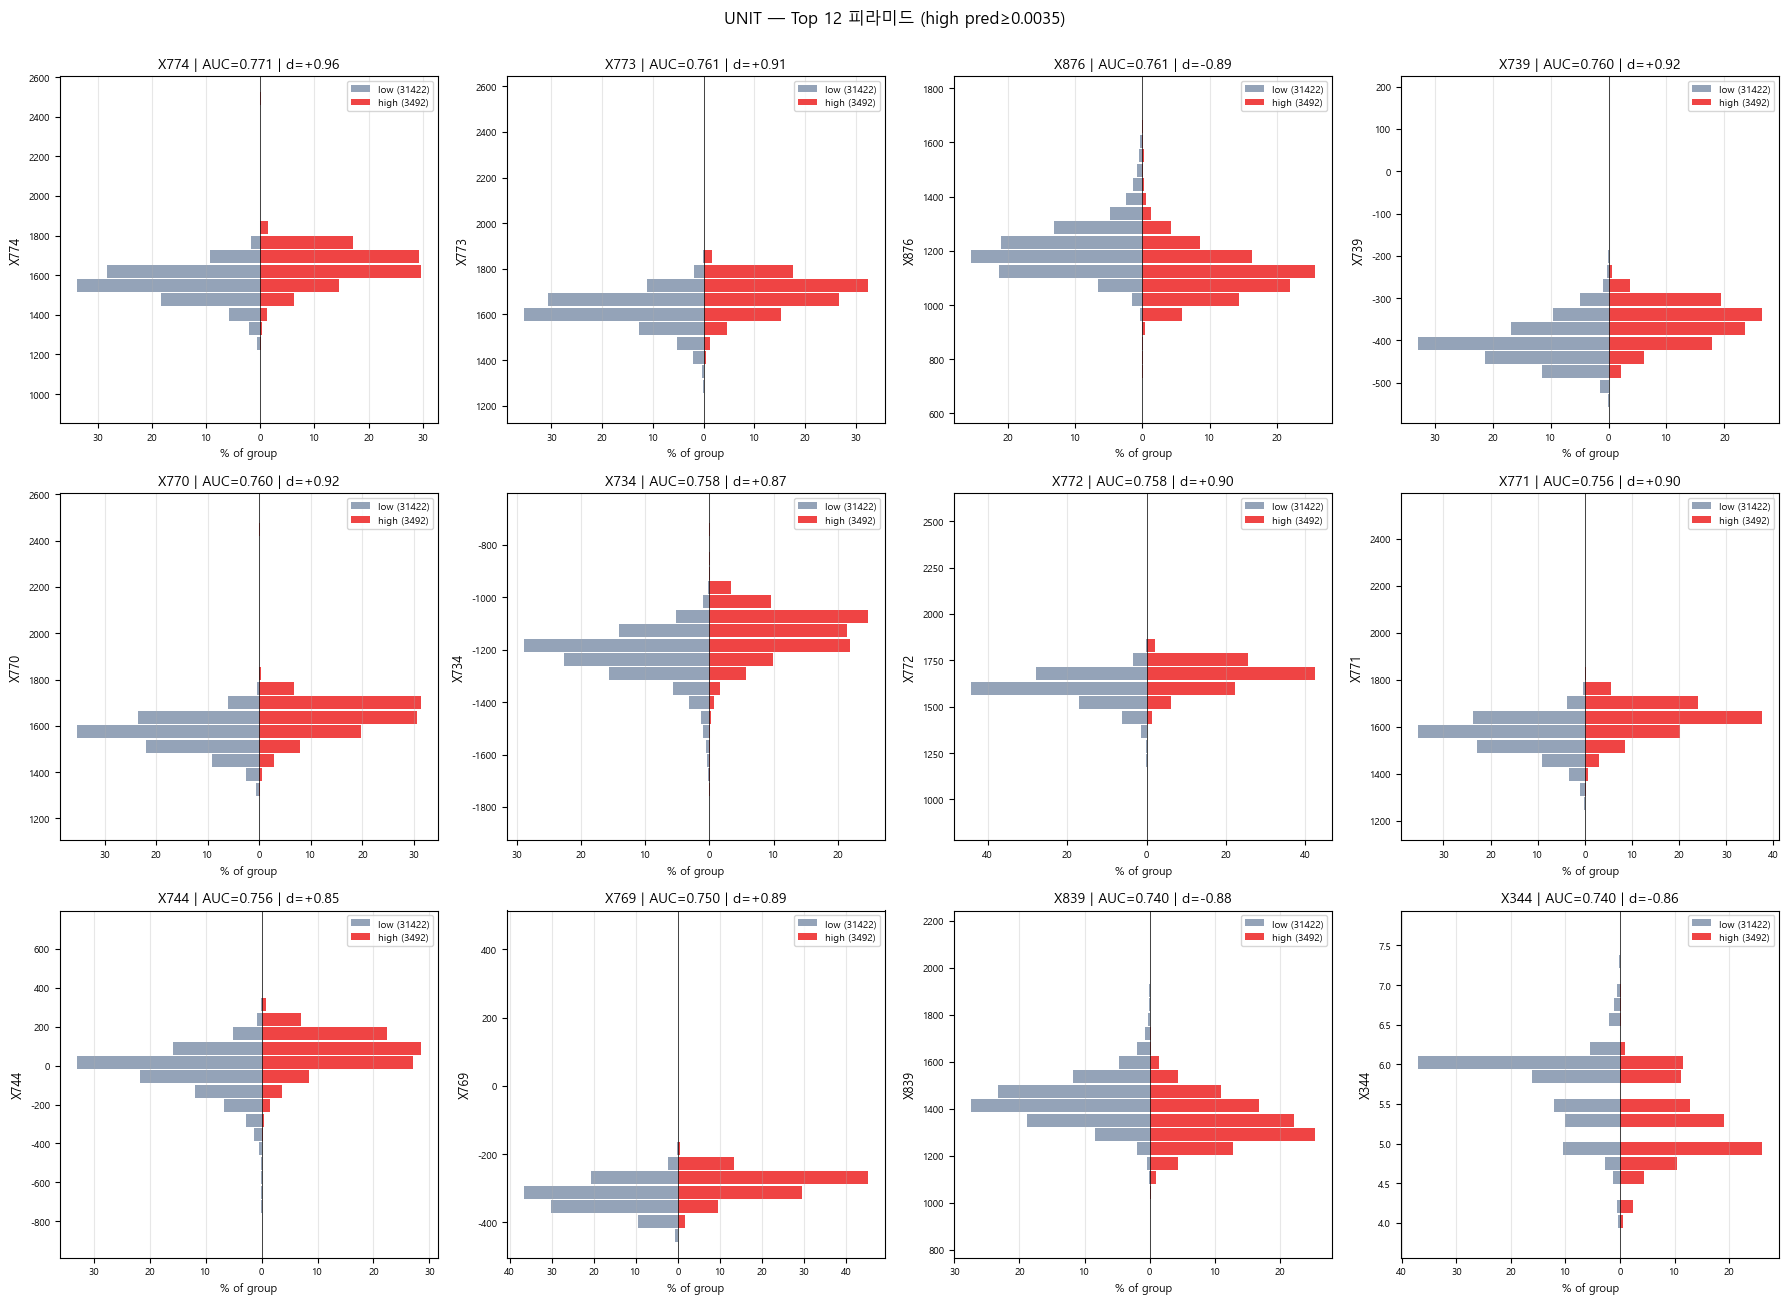

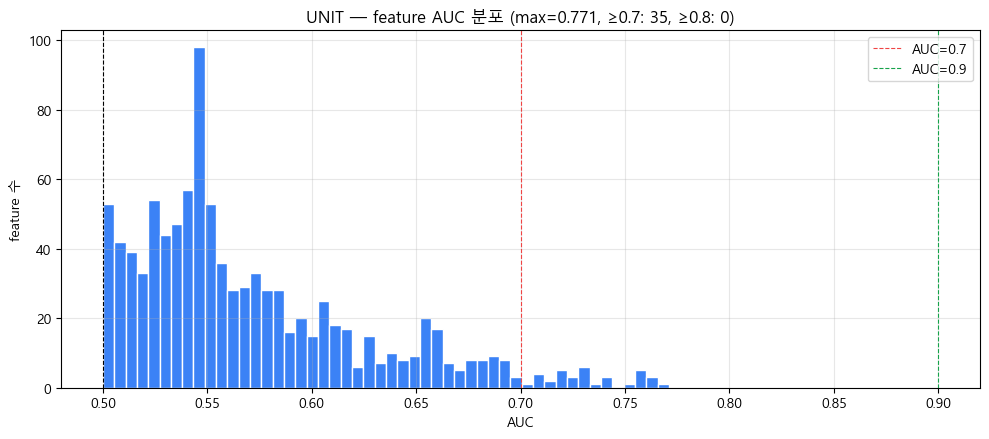

In [10]:
plot_top_pyramids(unit_x, auc_unit, f'UNIT — Top {TOP_N_PYRAMID} 피라미드 (high pred≥{thr_u:.4f})')
plot_auc_hist(auc_unit, 'UNIT — feature AUC 분포')

### B-탐색: UNIT 파라미터 진단

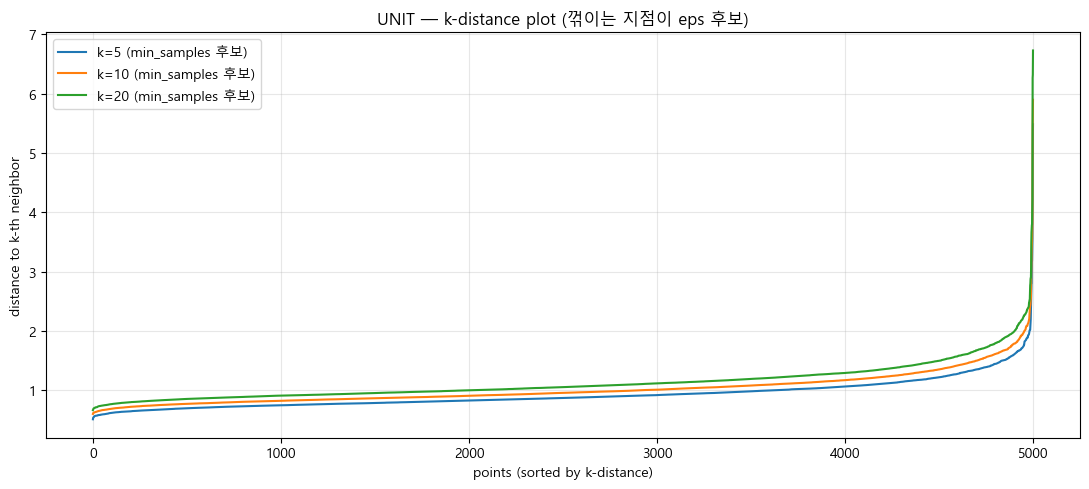

  추천 eps 후보 (k=10 분위수):
    80-pct: eps ≈ 1.169
    85-pct: eps ≈ 1.240
    90-pct: eps ≈ 1.349
    95-pct: eps ≈ 1.552
  PCA cumulative variance:
    80% 도달: component 2개
    90% 도달: component 3개
    95% 도달: component 5개


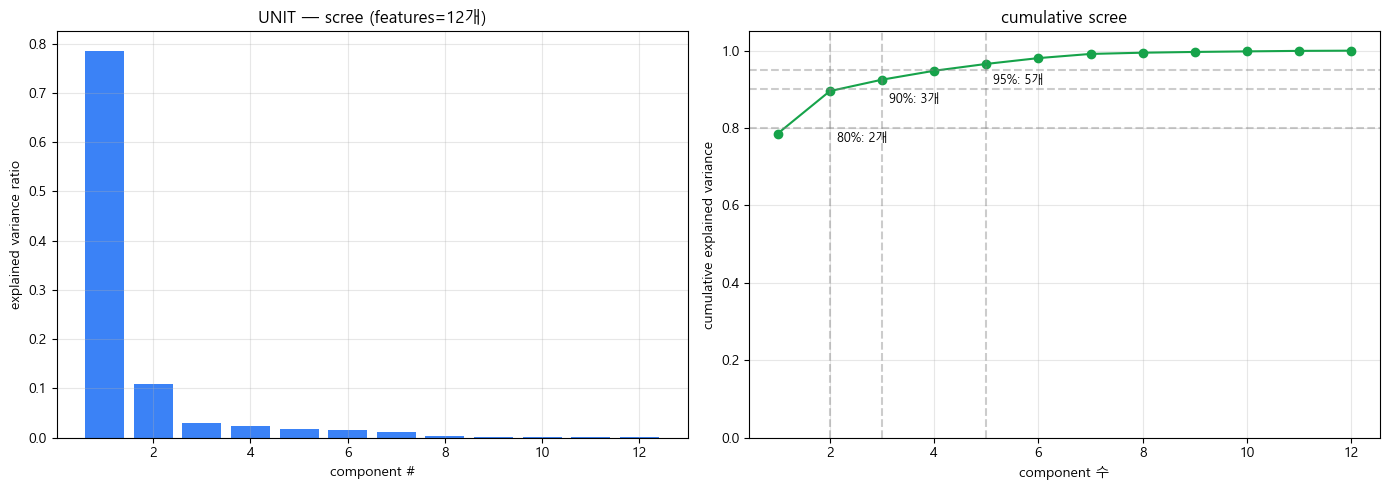

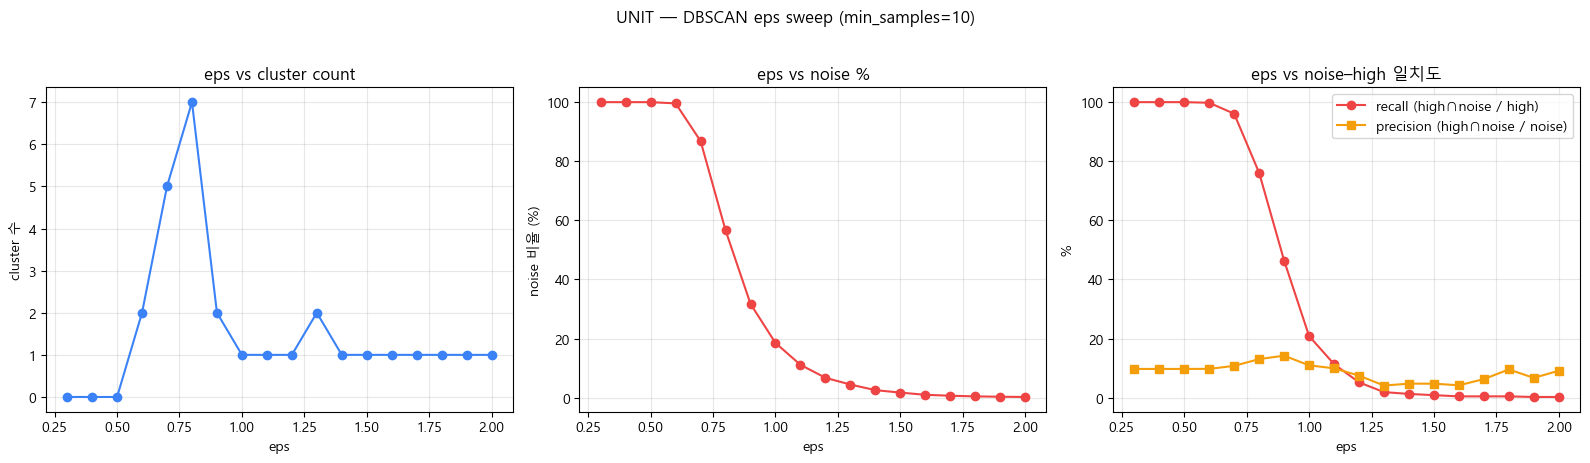

,eps,n_cluster,noise_pct,recall_high,precision_high
0,0.3,0,100.00,100.00,9.70
1,0.4,0,100.00,100.00,9.70
2,0.5,0,100.00,100.00,9.70
3,0.6,2,99.58,99.79,9.72
4,0.7,5,86.82,96.08,10.73
5,0.8,7,56.62,76.08,13.03
6,0.9,2,31.72,46.39,14.19
7,1.0,1,18.50,20.82,10.92
8,1.1,1,11.10,11.34,9.91
9,1.2,1,6.72,5.15,7.44


In [11]:
plot_k_distance(unit_x, x_cols, 'UNIT', top_k=TOP_K_DBSCAN, auc_df=auc_unit)
plot_pca_scree(unit_x, x_cols, 'UNIT', top_k=TOP_K_DBSCAN, auc_df=auc_unit)
swp_unit = dbscan_sweep(unit_x, x_cols, 'UNIT', top_k=TOP_K_DBSCAN, auc_df=auc_unit,
                         min_samples=10)
swp_unit.round(2)

### B-시각화: UNIT 산점도 + PCA + DBSCAN

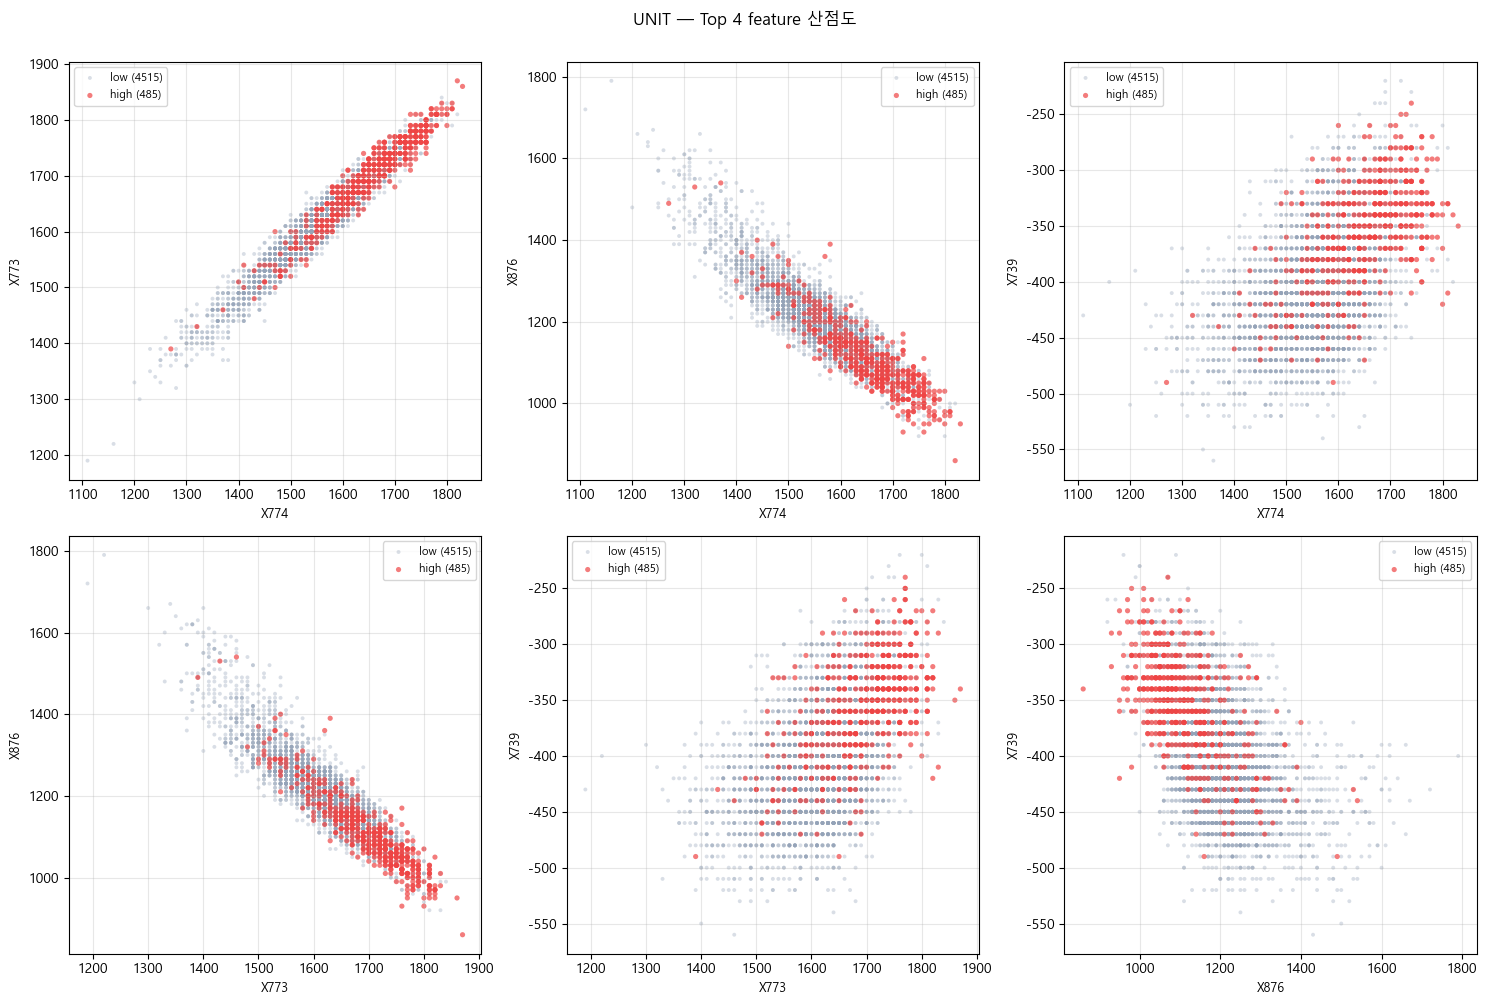

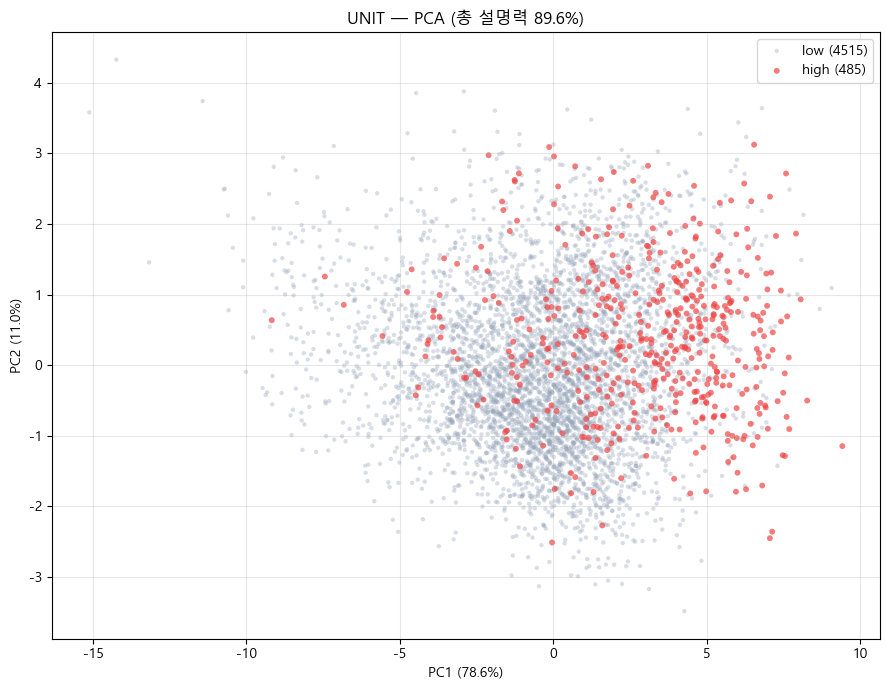

  DBSCAN input: n=5000, features=12, eps=0.9, min_samples=10
  cluster: 2, noise: 1586/5000


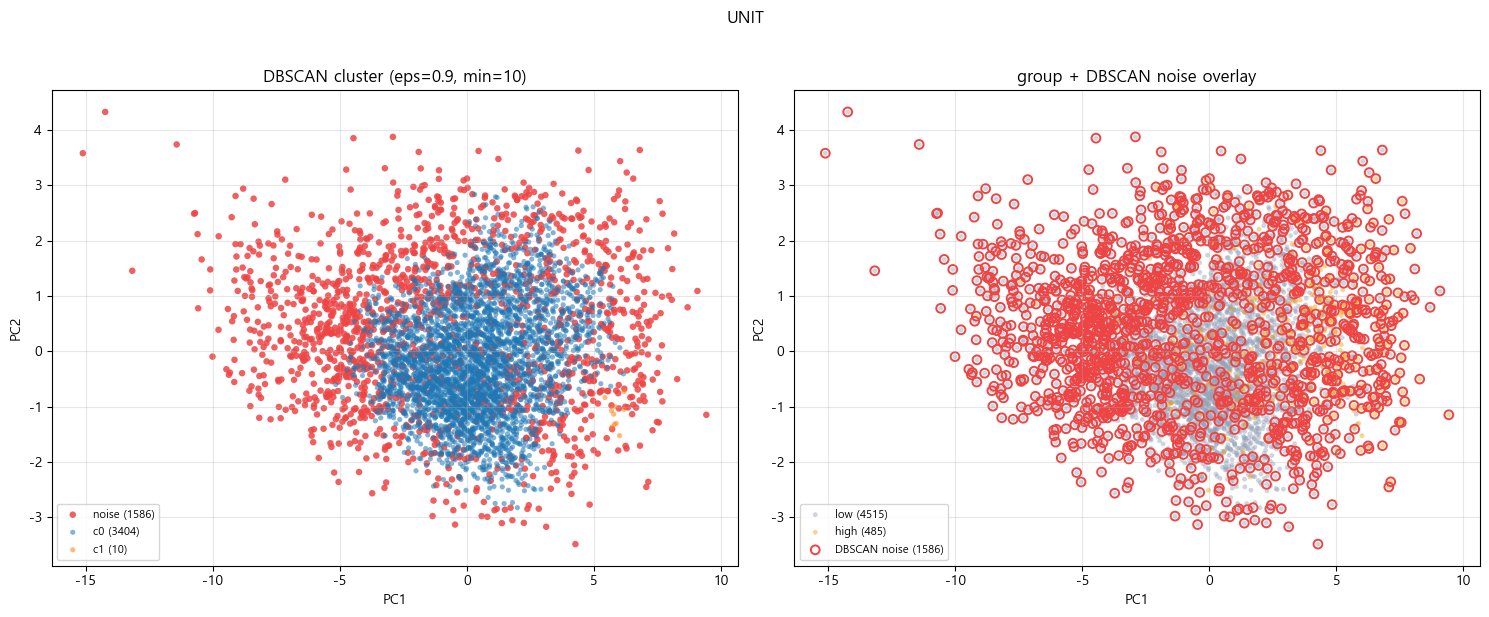

  group × noise:
noise  False  True 
group              
high     260    225
low     3154   1361


In [12]:
# 진단 결과 기반 최적값:
# - k-distance(k=10) elbow ≈ 1.0~1.3, 90-pct quantile = 1.35
# - eps sweep: eps=0.9에서 cluster=2 (안정), noise=32%, recall=46%, precision=14% (peak)
# - eps=0.8: cluster 7개로 분열 (불안정), eps>1.0: cluster=1 (과결합)
# - scree: 80%/90%/95% = 2/3/5 components → 2D PCA가 89.6%로 매우 높음
UNIT_EPS = 0.9
UNIT_MIN_SAMPLES = 10

plot_top_scatter_grid(unit_x, auc_unit, f'UNIT — Top {TOP_K_SCATTER} feature 산점도')
plot_pca_scatter(unit_x, x_cols, 'UNIT', top_k=TOP_K_DBSCAN, auc_df=auc_unit)
plot_dbscan(unit_x, x_cols, 'UNIT', eps=UNIT_EPS, min_samples=UNIT_MIN_SAMPLES,
            top_k=TOP_K_DBSCAN, auc_df=auc_unit)

## C. DIE 단위 (~139,656 die)

그룹 정의: die-level **pred** 의 90-percentile.

In [13]:
d_d = die_pred[die_pred['split'].isin(USE_SPLITS)].copy()
thr_d = d_d['pred'].quantile(THR_PCT)
d_d['group'] = np.where(d_d['pred'] >= thr_d, 'high', 'low')
print(f'die thr (pred의 {THR_PCT*100:.0f}-pct) = {thr_d:.5f}')
print(d_d['group'].value_counts())

xs_d = xs[xs['run_wf_xy'].isin(d_d['run_wf_xy'])].copy()
die_x = xs_d.merge(d_d[['run_wf_xy', 'group']], on='run_wf_xy', how='inner')
print(f'die_x: {die_x.shape}')

auc_die = compute_auc_table(die_x[x_cols + ['group']], x_cols)
print(f'유효 feature: {len(auc_die)}, ≥0.7: {(auc_die["auc"]>=0.7).sum()}, '
      f'≥0.8: {(auc_die["auc"]>=0.8).sum()}, max: {auc_die["auc"].max():.3f}')
auc_die.head(15)

die thr (pred의 90-pct) = 0.00347
group
low     125690
high     13966
Name: count, dtype: int64
die_x: (139656, 1092)
유효 feature: 988, ≥0.7: 9, ≥0.8: 0, max: 0.729


,feature,auc,cohen_d,mean_high,mean_low
0,X1049,0.728561,-0.497126,84988.491766,90105.522126
1,X774,0.721748,0.748510,1638.977517,1557.995067
2,X744,0.713412,0.701944,66.481455,-28.120296
3,X773,0.708307,0.688498,1685.006444,1618.268438
4,X770,0.705999,0.687318,1631.356151,1566.702840
5,X772,0.704075,0.673477,1662.672204,1598.282441
6,X771,0.702763,0.673176,1626.687670,1562.615005
7,X876,0.700881,-0.675642,1126.247046,1204.045351
8,X734,0.700628,0.667934,-1148.715452,-1226.767762
9,X839,0.690206,-0.682854,1350.949449,1432.743301


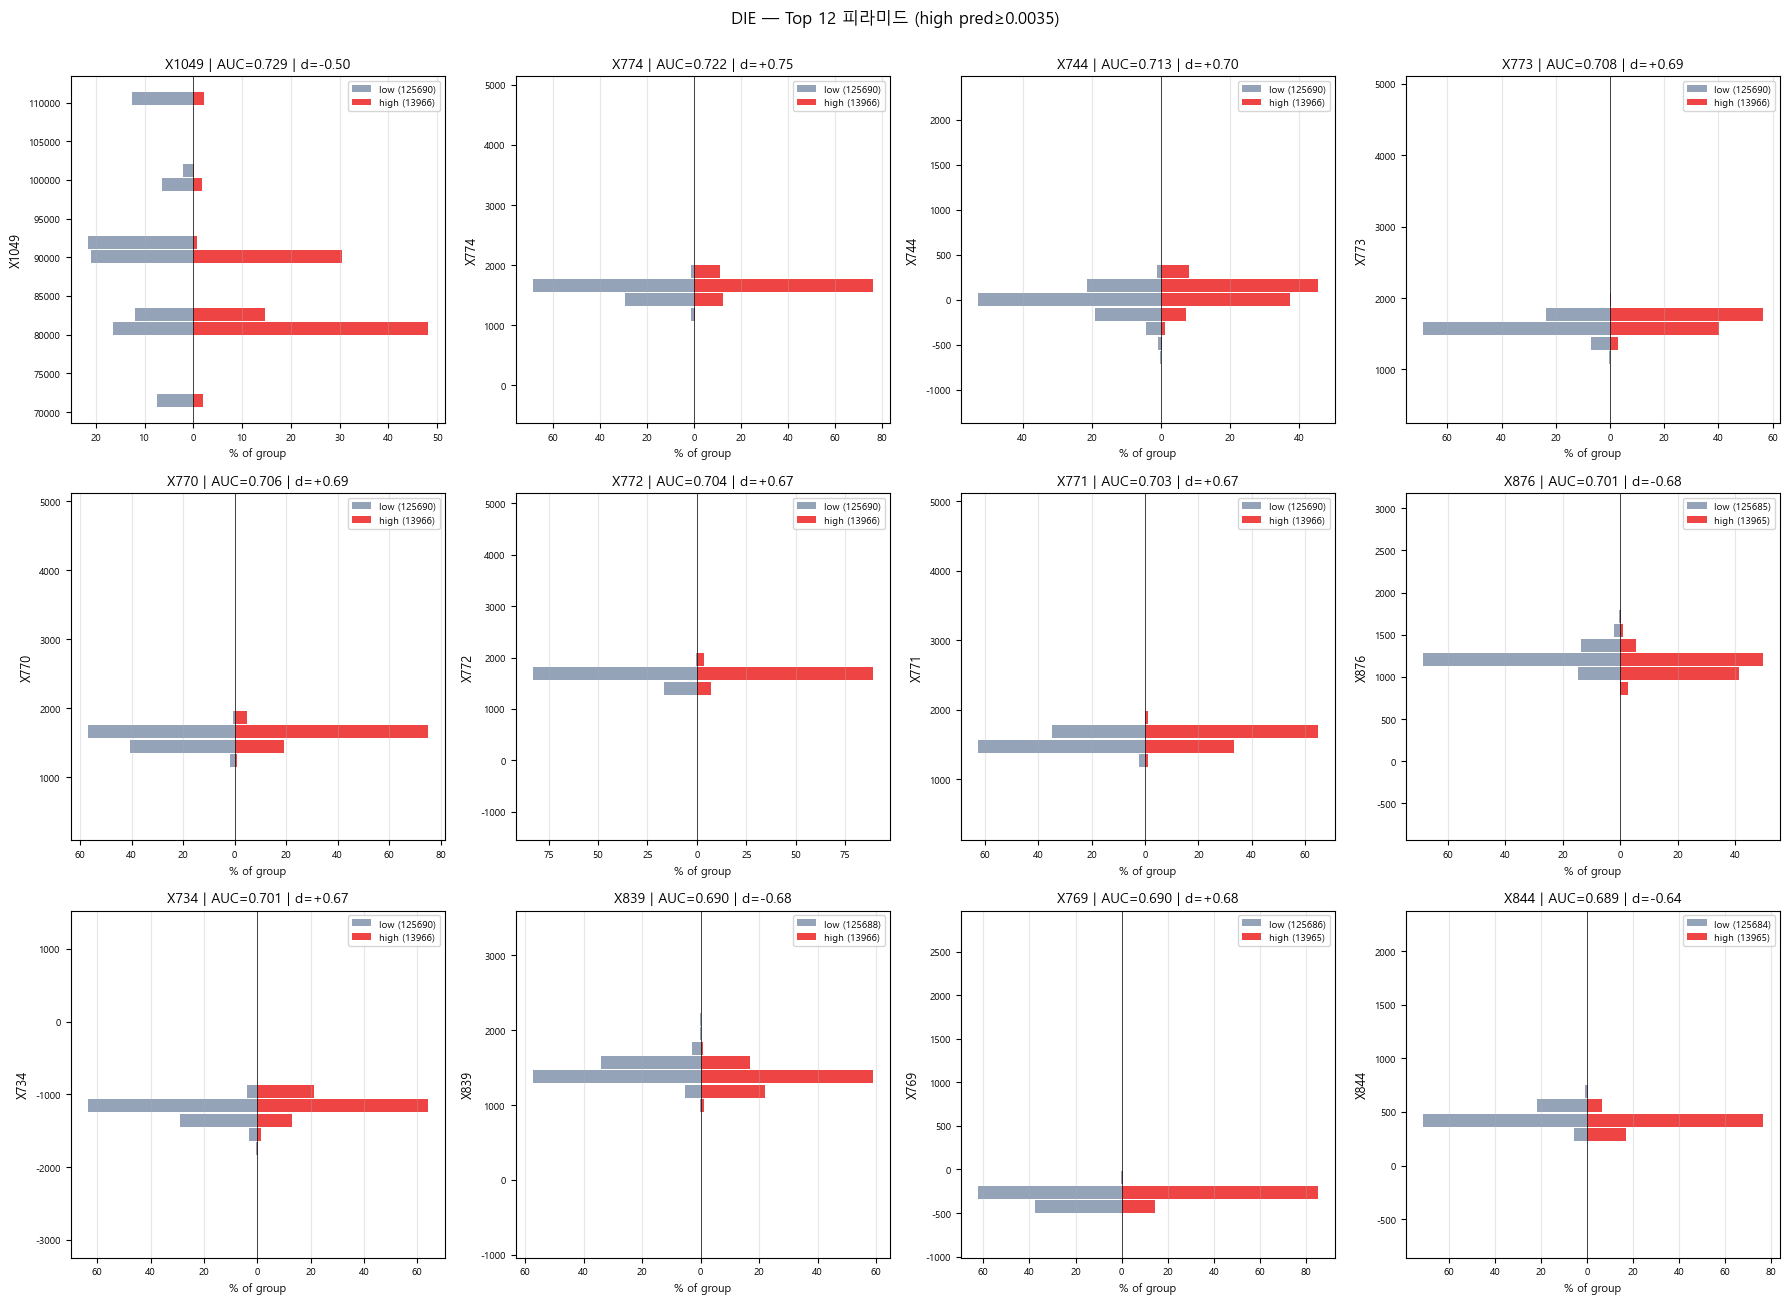

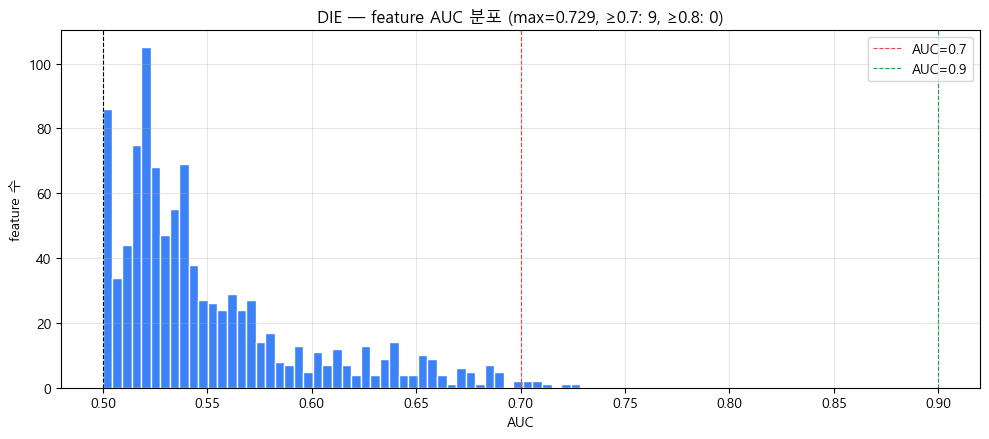

In [14]:
plot_top_pyramids(die_x, auc_die, f'DIE — Top {TOP_N_PYRAMID} 피라미드 (high pred≥{thr_d:.4f})')
plot_auc_hist(auc_die, 'DIE — feature AUC 분포')

### C-탐색: DIE 파라미터 진단

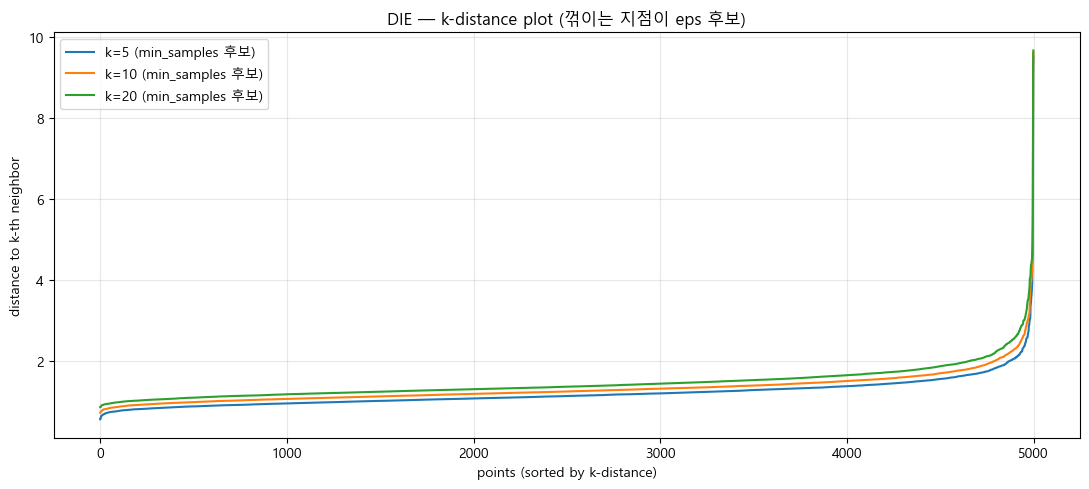

  추천 eps 후보 (k=10 분위수):
    80-pct: eps ≈ 1.502
    85-pct: eps ≈ 1.574
    90-pct: eps ≈ 1.695
    95-pct: eps ≈ 1.917
  PCA cumulative variance:
    80% 도달: component 3개
    90% 도달: component 4개
    95% 도달: component 6개


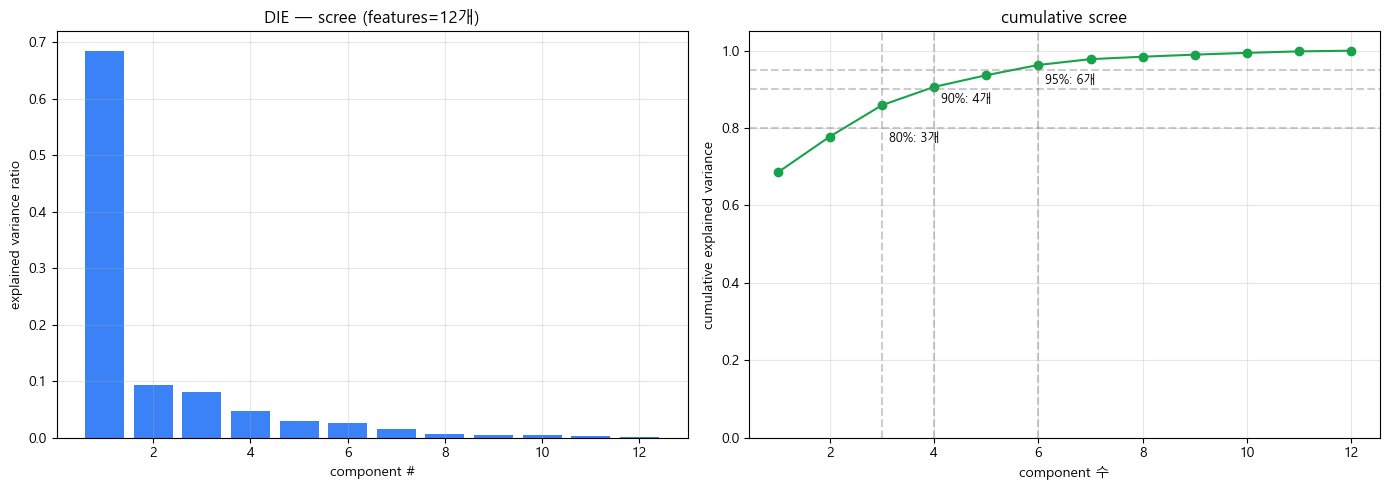

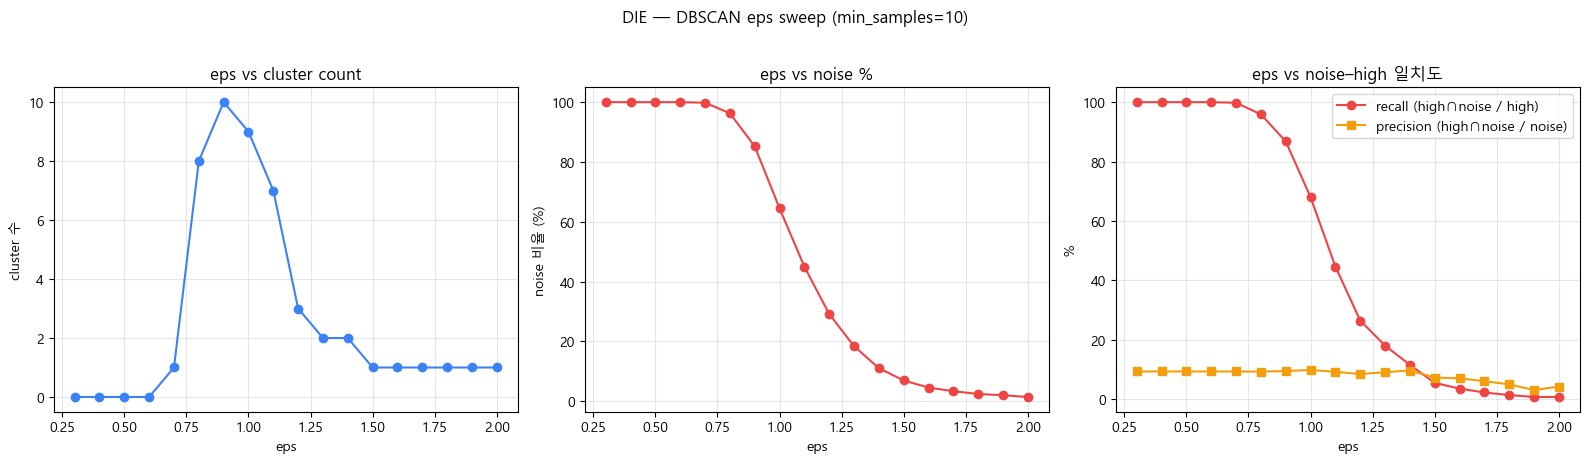

,eps,n_cluster,noise_pct,recall_high,precision_high
0,0.3,0,100.00,100.00,9.24
1,0.4,0,100.00,100.00,9.24
2,0.5,0,100.00,100.00,9.24
3,0.6,0,100.00,100.00,9.24
4,0.7,1,99.80,99.78,9.24
5,0.8,8,96.30,95.89,9.20
6,0.9,10,85.26,86.80,9.41
7,1.0,9,64.54,67.97,9.73
8,1.1,7,45.02,44.59,9.15
9,1.2,3,29.20,26.41,8.36


In [15]:
plot_k_distance(die_x, x_cols, 'DIE', top_k=TOP_K_DBSCAN, auc_df=auc_die)
plot_pca_scree(die_x, x_cols, 'DIE', top_k=TOP_K_DBSCAN, auc_df=auc_die)
swp_die = dbscan_sweep(die_x, x_cols, 'DIE', top_k=TOP_K_DBSCAN, auc_df=auc_die,
                        min_samples=10)
swp_die.round(2)

### C-시각화: DIE 산점도 + PCA + DBSCAN

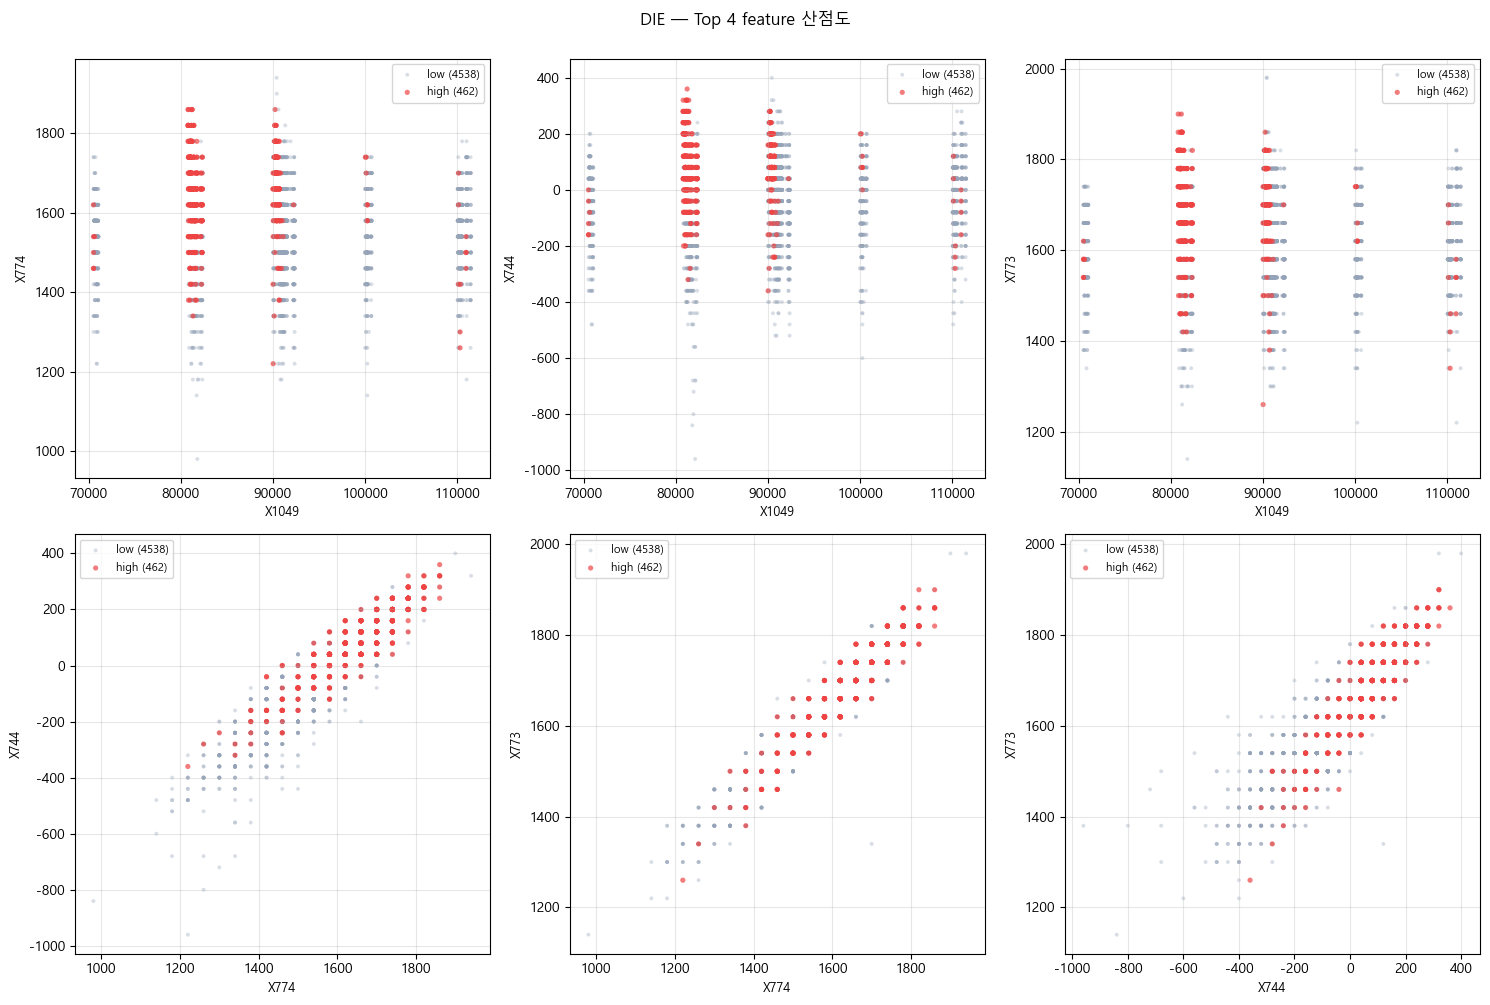

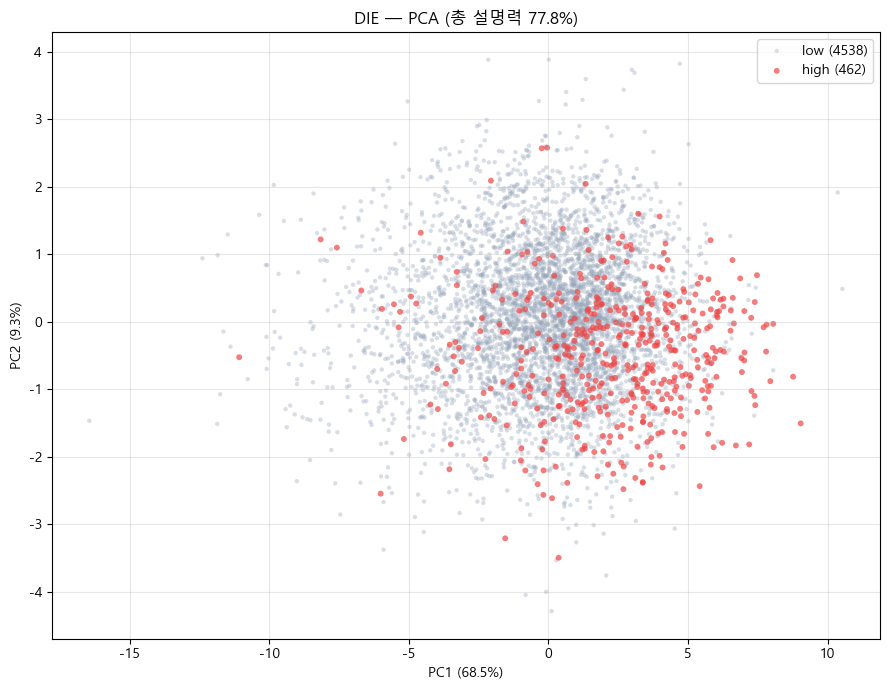

  DBSCAN input: n=5000, features=12, eps=1.3, min_samples=10
  cluster: 2, noise: 921/5000


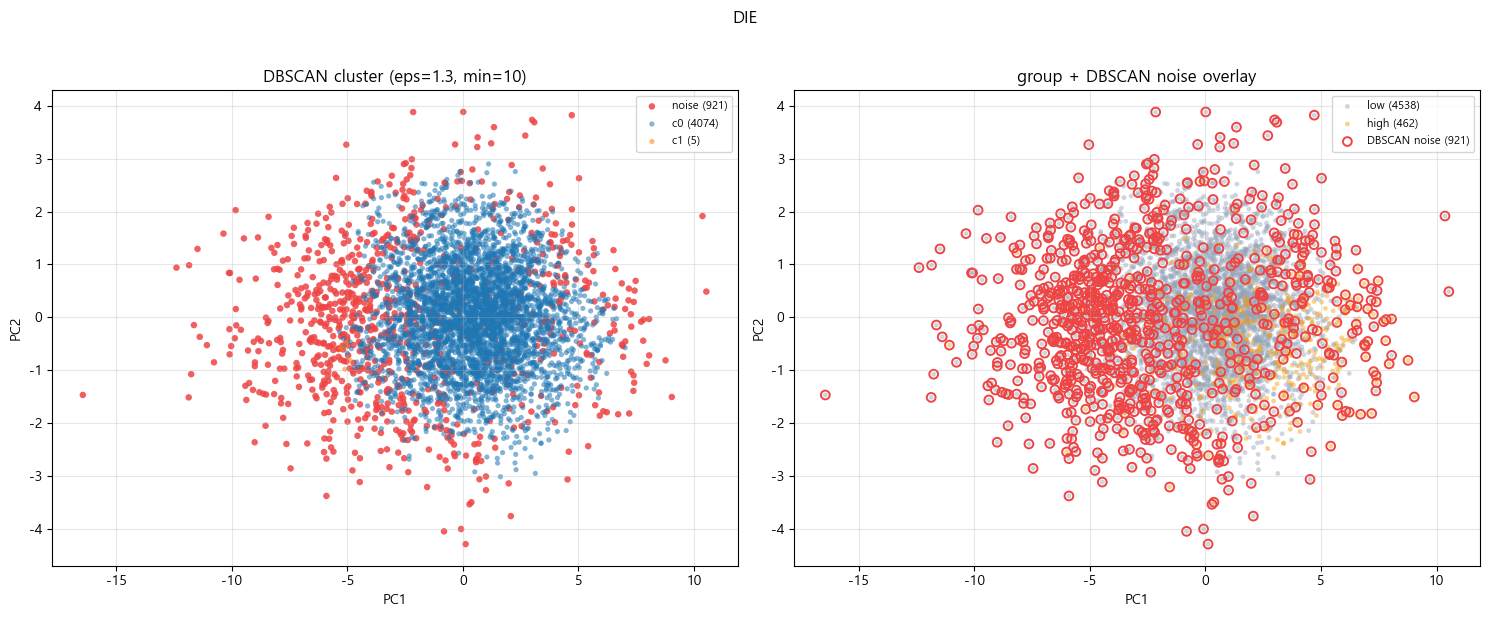

  group × noise:
noise  False  True 
group              
high     379     83
low     3700    838


In [16]:
# 진단 결과 기반 최적값:
# - k-distance(k=10) elbow ≈ 1.3~1.5, 90-pct quantile = 1.70
# - eps sweep: eps=1.3에서 cluster=2 (안정), noise=18%, precision ~10% (base rate)
# - 주의: die 단위는 precision이 base rate(9.2%) 근처로 거의 평탄 — DBSCAN의 anomaly 변별력 약함
# - scree: 80%/90%/95% = 3/4/6 components → 2D PCA(77.8%)는 적당
DIE_EPS = 1.3
DIE_MIN_SAMPLES = 10

plot_top_scatter_grid(die_x, auc_die, f'DIE — Top {TOP_K_SCATTER} feature 산점도')
plot_pca_scatter(die_x, x_cols, 'DIE', top_k=TOP_K_DBSCAN, auc_df=auc_die)
plot_dbscan(die_x, x_cols, 'DIE', eps=DIE_EPS, min_samples=DIE_MIN_SAMPLES,
            top_k=TOP_K_DBSCAN, auc_df=auc_die)

## 3단위 종합

In [17]:
summary = pd.DataFrame({
    'level': ['wafer', 'unit', 'die'],
    'n_samples': [wafer_x.shape[0], unit_x.shape[0], die_x.shape[0]],
    'n_high': [(wafer_x['group']=='high').sum(),
                (unit_x['group']=='high').sum(),
                (die_x['group']=='high').sum()],
    'max_auc': [auc_wafer['auc'].max(), auc_unit['auc'].max(), auc_die['auc'].max()],
    'auc≥0.7': [(auc_wafer['auc']>=0.7).sum(),
                 (auc_unit['auc']>=0.7).sum(),
                 (auc_die['auc']>=0.7).sum()],
    'auc≥0.8': [(auc_wafer['auc']>=0.8).sum(),
                 (auc_unit['auc']>=0.8).sum(),
                 (auc_die['auc']>=0.8).sum()],
})
summary

,level,n_samples,n_high,max_auc,auc≥0.7,auc≥0.8
0,wafer,431,44,0.831307,136,3
1,unit,34914,3492,0.771058,35,0
2,die,139656,13966,0.728561,9,0


In [18]:
top20 = pd.DataFrame({
    'wafer_top': auc_wafer.head(20)['feature'].tolist(),
    'unit_top':  auc_unit.head(20)['feature'].tolist(),
    'die_top':   auc_die.head(20)['feature'].tolist(),
})
common = set(top20['wafer_top']) & set(top20['unit_top']) & set(top20['die_top'])
print(f'3단위 모두 Top 20에 든 feature: {len(common)}개')
print(sorted(common))
top20

3단위 모두 Top 20에 든 feature: 11개
['X734', 'X739', 'X744', 'X769', 'X770', 'X771', 'X772', 'X773', 'X774', 'X844', 'X876']


,wafer_top,unit_top,die_top
0,X769,X774,X1049
1,X344,X773,X774
2,X739,X876,X744
3,X774,X739,X773
4,X876,X770,X770
5,X844,X734,X772
6,X734,X772,X771
7,X870,X771,X876
8,X744,X744,X734
9,X871,X769,X839
